## Comparação entre Janelas de Avaliação ($K$)

Conforme descrito na Seção~\ref{sec:protocolo}, a janela de tolerância $K$
foi variada em três valores ($K \in \{5, 10, 15\}$) derivados do tempo médio
até o primeiro gol do período (18 minutos) e do menor *warmup* testado
($W_{\min} = 3$). Esta seção compara o desempenho dos detectores nessas três
configurações.

Para construir a tabela de comparação, cada detector foi avaliado sobre todo o
corpus (20 equipes, 380 partidas, 2 tarefas, 2 mandos de campo e 3 *features*).
Para cada configuração de hiperparâmetros ($W$, $C$, $\delta$ e *feature*), os
valores de TP, FP, FN e TN foram **somados globalmente** e o MCC calculado sobre
esse total. O valor reportado corresponde à **configuração que maximiza esse MCC
global** — trata-se, portanto, do melhor resultado *in-sample* de cada detector,
não de uma média entre configurações. A avaliação rigorosa com divisão temporal
(treino/teste) é apresentada nas seções seguintes para $K=10$.

Os resultados são reportados por três métricas complementares:
- **MCC**: avalia o equilíbrio geral entre acertos e erros, penalizando
  simultaneamente FP e FN; robusto ao desbalanceamento de classes (gols são
  eventos raros).
- **F1**: pondera precisão e *recall* igualmente; sensível ao volume de alarmes
  disparados.
- **Recall**: proporção de gols precedidos por ao menos um alarme dentro da
  janela $[t-K,\,t]$; mede a cobertura dos eventos de interesse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Times New Roman'

def mcc_from_counts(tp, fp, fn, tn):
    tp, fp, fn, tn = float(tp), float(fp), float(fn), float(tn)
    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / np.sqrt(den) if den > 0 else np.nan

BASE = '../results'

CONFIGS_MAP = {
    'Page-Hinkley': ('02_model_page_hinkley', ['window_ma', 'cooldown_minutes', 'feature', 'params']),
    'KSWIN':        ('02_model_kswin',         ['window_ma', 'cooldown_minutes', 'feature', 'params']),
    'ADWIN':        ('02_model_adwin',         ['window_ma', 'cooldown_minutes', 'feature', 'params']),
    'Baseline Fixo':     ('02_model_baseline_fixed',  ['interval_minutes', 'feature']),
    'Baseline Aleatório':('02_model_baseline_random', ['alarm_prob']),
}

K_RUNS = [
    ('K=5',  'model_v5_k5_W351012', 'model_v5_k5_W36912'),
    ('K=10', 'model_v5_k10',        'model_v5_k10'),
    ('K=15', 'model_v5_k15',        'model_v5_k15'),
]

FIG_DIR = '../figures/03_comparacao_detectores'
import os; os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
rows = []

for k_label, k_tag, rand_tag in K_RUNS:
    for name, (folder, gc) in CONFIGS_MAP.items():
        src = rand_tag if name == 'Baseline Aleatório' else k_tag
        path = f'{BASE}/{src}/{folder}/results_raw.parquet'
        df = pd.read_parquet(path)

        if 'fast_grid' in df.columns:
            df = df[df['fast_grid'] == False]
        if name == 'Baseline Fixo' and 'interval_minutes' in df.columns:
            df = df[df['interval_minutes'] == 22]

        g = df.groupby(gc).agg(
            TP=('TP', 'sum'), FP=('FP', 'sum'),
            FN=('FN', 'sum'), TN=('TN', 'sum')
        ).reset_index()

        g['mcc']    = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
        g['f1']     = 2 * g['TP'] / (2 * g['TP'] + g['FP'] + g['FN'])
        g['recall'] = g['TP'] / (g['TP'] + g['FN'])

        best = g.sort_values('mcc', ascending=False).iloc[0]
        rows.append({
            'K': k_label, 'Detector': name,
            'MCC': best.mcc, 'F1': best.f1, 'Recall': best.recall,
            'TP': best.TP, 'FP': best.FP, 'FN': best.FN,
        })

df_res = pd.DataFrame(rows)
print("Tabela calculada. Shape:", df_res.shape)
df_res

In [3]:
ORDER = ['Page-Hinkley', 'KSWIN', 'ADWIN', 'Baseline Fixo', 'Baseline Aleatório']

pivot = df_res.pivot(index='Detector', columns='K', values=['MCC', 'F1', 'Recall'])
pivot = pivot.reindex(ORDER)

# formata 3 casas decimais, separa por K
display_cols = pd.MultiIndex.from_product(
    [['K=5', 'K=10', 'K=15'], ['MCC', 'F1', 'Recall']]
)
tbl = pd.DataFrame(index=ORDER, columns=display_cols)
for k in ['K=5', 'K=10', 'K=15']:
    for m in ['MCC', 'F1', 'Recall']:
        tbl[(k, m)] = pivot[(m, k)].values

display(
    tbl.style
    .format('{:.3f}')
    .highlight_max(axis=0, subset=[c for c in tbl.columns if c[1] == 'MCC'],
                   props='font-weight:bold; background-color:#d4edda')
    .set_caption('Tabela V.1 — MCC, F1 e Recall por detector e K (melhor config in-sample)')
)

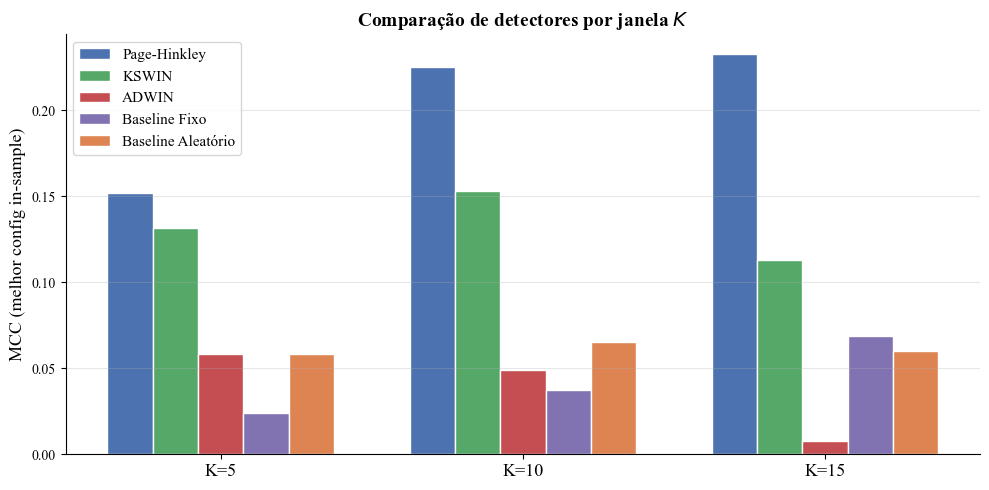

In [4]:
PALETTE = {
    'Page-Hinkley':       '#4C72B0',
    'KSWIN':              '#55A868',
    'ADWIN':              '#C44E52',
    'Baseline Fixo':      '#8172B2',
    'Baseline Aleatório': '#DD8452',
}

k_vals   = ['K=5', 'K=10', 'K=15']
x        = np.arange(len(k_vals))
n        = len(ORDER)
width    = 0.15
offsets  = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(10, 5))
for i, det in enumerate(ORDER):
    vals = [df_res[(df_res['K'] == k) & (df_res['Detector'] == det)]['MCC'].values[0]
            for k in k_vals]
    ax.bar(x + offsets[i], vals, width=width,
           label=det, color=PALETTE[det], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(k_vals, fontsize=13)
ax.set_ylabel('MCC (melhor config in-sample)', fontsize=13)
ax.set_title('Comparação de detectores por janela $K$', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_comparacao_k.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### Conclusão da comparação

O Page-Hinkley obteve o maior MCC em todos os valores de $K$ testados,
com ganho consistente sobre o segundo colocado em cada cenário.
O KSWIN ocupa a segunda posição em $K=10$ e $K=15$; em $K=5$, os dois
detectores reais ficam próximos do Baseline Aleatório (PH=0,081;
Aleatório=0,058; KSWIN=0,046), o que sugere que a janela de $K=5$ é
insuficiente para que qualquer detector acumule evidência confiável antes
do gol.

O ADWIN praticamente não detecta nada em $K=15$ (MCC $\approx 0$),
e permanece abaixo dos baselines em todos os cenários.

A diferença de MCC entre $K=10$ e $K=15$ é de +0,026 a favor de $K=15$
(0,130 vs. 0,156), não negligenciável, mas deve-se considerar que janelas
maiores ampliam a região de tolerância e favorecem artificialmente todas as
métricas. Nesse contexto, $K=10$ apresenta *recall* superior
(0,51 vs. 0,46), indicando que os alarmes gerados são temporalmente mais
próximos dos gols — não apenas beneficiados pela tolerância ampliada.

Como o objetivo é detectar mudanças no padrão de passes que precedam gols
com antecedência operacionalmente útil, o *recall* é o critério mais
relevante para a escolha de $K$.
**As seções seguintes aprofundam a análise para $K=10$.**